# **Proyecto 01: Modelos de regresión para la predicción de calificaciones de examenes de estudiantes**

---
Nombres:\
**Claudio Alejo Encarnación Martínez (750597)** \
**Juan Pablo Morán (753760)** \
**Alan Jesús Hernández Soto (752714)** 

Carrera: **Ingeniería Financiera** \
Materia: **Laboratorio de Aprendizaje Estadístico** \
Tipo de Trabajo: **Proyecto**

---

## 1. Objetivos

### 1.1 Generales
Predecir e interpretar el desempeño de estudiantes en un examen (`Exam_Score`) a partir de factores académicos, personales, familiares y escolares, mediante la comparación de tres especificaciones de regresión (lineal, polinomial y con interacciones) ajustadas en cuatro versiones (sin penalización, Ridge, Lasso y ElasticNet), para identificar qué especificación representa mejor las relaciones presentes en los datos, qué método de regularización generaliza mejor y qué factores presentan mayor asociación predictiva con el desempeño.

### 1.2 Específicos
1. **Analizar el conjunto de datos** `StudentPerformanceFactors.csv` en cuanto a su origen, contenido, calidad y estructura, identificando valores faltantes, valores fuera de rango, tipos de variables y posibles transformaciones necesarias para su uso en modelos de regresión.

2. **Construir un pipeline de preprocesamiento** que incluya limpieza de datos, imputación de valores faltantes, codificación de variables categóricas (ordinales y binarias), escalamiento de variables numéricas y partición de entrenamiento y prueba, garantizando que todas las transformaciones se ajusten únicamente con los datos de entrenamiento.

3. **Definir tres especificaciones de regresión**: una lineal múltiple sin interacciones, una polinomial con términos seleccionados y una con interacciones justificadas entre factores, cada una en cuatro versiones: sin penalización (OLS), Ridge, Lasso y ElasticNet.

4. **Seleccionar los hiperparámetros (Alpha) de penalización** de las versiones Ridge, Lasso y ElasticNet mediante validación cruzada de 5 folds con `GridSearchCV`, usando R² como métrica de optimización.

5. **Ajustar y comparar los doce modelos resultantes** mediante métricas de desempeño (R², RMSE) en entrenamiento y prueba, con visualizaciones que permitan identificar diferencias entre especificaciones y entre versiones de penalización.

6. **Realizar un análisis de residuos** sobre los 3 modelos sin penalización para evaluar los seis supuestos clásicos de la regresión: no linealidad, correlación en errores, varianza no constante, outliers, puntos palanca y colinealidad, y proponer las transformaciones pertinentes a partir de los resultados.

7. **Analizar la significancia de los factores** en los 3 modelos sin penalización, mediante pruebas t individuales y la prueba F global, identificando qué factores se asocian significativamente con `Exam_Score`, y reportando el signo, magnitud e intervalos de confianza de los coeficientes estimados.

8. **Comparar los resultados entre las tres especificaciones y las cuatro versiones** para determinar qué combinación logra el mejor equilibrio entre capacidad predictiva, interpretabilidad y estabilidad, y **concluir respecto al objetivo general** sobre qué factores y qué tipo de modelo describen mejor el desempeño en el examen.

## 2. Marco Teórico

### 2.1 Regresión lineal

La regresión lineal es un método de aprendizaje supervisado utilizado para predecir una variable cuantitativa a partir de una o más variables predictoras, es decir es una relación de variables. En este proyecto, la variable respuesta será la calificación obtenida en el examen, mientras que las variables predictoras serán los factores disponibles en el conjunto de datos *Student Performance Factor*.

En su forma múltiple, el modelo se expresa como:

$$
Y_i = \beta_0 + \beta_1X_{i1} + \beta_2X_{i2} + \cdots + \beta_pX_{ip} + \varepsilon_i
$$

donde:

- $Y_i$ es la calificación observada del estudiante $i$.
- $\beta_0$ es el intercepto.
- $\beta_j$ representa el cambio esperado en $Y$ en base a un incremento de una unidad en $X_j$, manteniendo constantes los demás factores.
- $\varepsilon_i$ representa el error aleatorio no explicado por el modelo.

Los coeficientes se estiman habitualmente mediante mínimos cuadrados ordinarios (OLS), que minimizan la suma de cuadrados de los residuos:

$$
RSS = \sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

El residuo $e_i=y_i-\hat{y}_i$ es la diferencia entre la calificación observada y la predicha. Un modelo con residuos pequeños tiende a ajustarse mejor a los datos de entrenamiento, aunque el desempeño debe verificarse también con datos no utilizados durante el ajuste.

Para evaluar el ajuste pueden emplearse métricas como el error cuadrático medio (MSE), la raíz del error cuadrático medio (RMSE), el error absoluto medio (MAE) y el coeficiente de determinación $R^2$. El valor de $R^2$ representa la proporción de variabilidad de la respuesta explicada por el modelo; sin embargo, debe complementarse con métricas de prueba o validación cruzada para evitar conclusiones basadas únicamente en el entrenamiento.

### 2.2 Regresión polinomial

La regresión polinomial permite modelar relaciones no lineales entre una variable predictora y la respuesta, manteniendo un modelo lineal respecto a sus coeficientes. Por ejemplo, un modelo cuadrático para una variable $X$ se expresa como:

$$
Y_i = \beta_0 + \beta_1X_i + \beta_2X_i^2 + \varepsilon_i
$$

De forma general, un polinomio de grado $d$ es:

$$
Y_i = \beta_0 + \beta_1X_i + \beta_2X_i^2 + \cdots + \beta_dX_i^d + \varepsilon_i
$$

Aunque la relación entre $X$ y $Y$ puede ser curva, el modelo sigue siendo lineal porque los parámetros $\beta_j$ se estiman linealmente. Este enfoque es útil si los gráficos de dispersión o de residuos muestran curvatura que una regresión lineal simple no puede representar.

Un grado polinomial alto aumenta la flexibilidad del modelo, pero también el riesgo de sobreajuste: el modelo puede aprender ruido específico de los datos de entrenamiento y generalizar mal. Por ello, el grado debe elegirse mediante validación cruzada y comparando el error de prueba.

### 2.3 Interacción de factores

Existe una interacción cuando el efecto de una variable predictora sobre la calificación depende del nivel de otra variable. Por ejemplo, el efecto de las horas de estudio podría ser distinto según las sesiones de tutoria del estudiante o el acceso a recursos educativos.

Para dos predictores $X_1$ y $X_2$, un modelo con interacción es:

$$
Y_i = \beta_0 + \beta_1X_{i1} + \beta_2X_{i2} + \beta_3(X_{i1}X_{i2}) + \varepsilon_i
$$

El término $X_1X_2$ representa la interacción. Al reorganizar el modelo se obtiene:

$$
Y_i = \beta_0 + (\beta_1+\beta_3X_{i2})X_{i1} + \beta_2X_{i2} + \varepsilon_i
$$

Por tanto, el efecto de $X_1$ deja de ser constante: depende de $X_2$. Si el coeficiente $\beta_3$ es relevante, incluir solamente los efectos principales puede producir una representación incompleta de la relación entre los factores y la calificación.

Debe respetarse el principio jerárquico: si se incorpora una interacción $X_1X_2$, también deben conservarse $X_1$ y $X_2$ en el modelo, aun cuando alguno de sus coeficientes individuales no resulte significativo.

### 2.4 Significancia de factores

La significancia estadística permite evaluar si existe evidencia de que un predictor tiene asociación con la respuesta, después de controlar por los demás predictores incluidos en el modelo.

Para cada factor se plantea, usualmente, la prueba de hipótesis:

$$
H_0:\beta_j=0
$$

$$
H_a:\beta_j\neq0
$$

El estadístico de prueba es:

$$
t = \frac{\hat{\beta}_j}{SE(\hat{\beta}_j)}
$$

donde $SE(\hat{\beta}_j)$ es el error estándar del coeficiente estimado. A partir de este estadístico se obtiene el *p-value*. Un *p-value* pequeño, comúnmente menor que $\alpha=0.05$, proporciona evidencia para rechazar $H_0$ y concluir que el factor está asociado con la calificación dentro del modelo planteado.

La significancia no equivale a causalidad ni garantiza una mejora importante en la predicción. Un factor puede tener un *p-value* pequeño y un efecto práctico reducido; también puede parecer no significativo cuando existe colinealidad con otros predictores. Por ello, la interpretación debe integrar el tamaño y signo del coeficiente, los intervalos de confianza, el conocimiento del problema y el desempeño predictivo.

La significancia global del modelo puede evaluarse mediante una prueba $F$, cuya hipótesis nula establece que todos los coeficientes de pendiente son iguales a cero:

$$
H_0:\beta_1=\beta_2=\cdots=\beta_p=0
$$

### 2.5 Regularización

La regularización modifica la función de costo de mínimos cuadrados al agregar una penalización sobre el tamaño de los coeficientes. Su objetivo es disminuir la varianza del modelo, reducir el sobreajuste y tratar de forma más estable conjuntos con variables correlacionadas o con muchas características.

Antes de ajustar modelos penalizados, las variables numéricas deben estandarizarse, ya que las penalizaciones dependen de la escala de los coeficientes. La selección del hiperparámetro de penalización debe realizarse con validación cruzada sobre el conjunto de entrenamiento.

#### 2.5.1 Ridge

La regresión Ridge utiliza una penalización $L2$:

$$
\min_{\beta}\left\{
RSS+\lambda\sum_{j=1}^{p}\beta_j^2
\right\}
$$

El parámetro $\lambda\geq0$ controla la intensidad de la penalización. Si $\lambda=0$, el modelo equivale a mínimos cuadrados ordinarios. Conforme $\lambda$ aumenta, los coeficientes se reducen hacia cero, pero normalmente no se vuelven exactamente cero.

Ridge es especialmente útil ante multicolinealidad, ya que estabiliza los coeficientes de predictores correlacionados. Conserva todas las variables, por lo que privilegia la predicción y la estabilidad sobre la selección explícita de factores.

#### 2.5.2 Lasso

La regresión Lasso utiliza una penalización $L1$:

$$
\min_{\beta}\left\{
RSS+\lambda\sum_{j=1}^{p}|\beta_j|
\right\}
$$

A diferencia de Ridge, Lasso puede llevar algunos coeficientes exactamente a cero. Por ello realiza selección automática de variables y genera modelos más escasos e interpretables.

Lasso puede ser conveniente si se espera que solo una parte de los factores disponibles influya de forma relevante en el resultado del examen. No obstante, cuando varios predictores están altamente correlacionados, puede conservar uno y excluir otros de manera inestable.

#### 2.5.3 ElasticNet

ElasticNet combina las penalizaciones Ridge y Lasso:

$$
\min_{\beta}\left\{
RSS+\lambda\left[
(1-\alpha)\frac{1}{2}\sum_{j=1}^{p}\beta_j^2+
\alpha\sum_{j=1}^{p}|\beta_j|
\right]
\right\}
$$

donde $\lambda$ controla la intensidad total de la penalización y $\alpha$ define la mezcla:

- $\alpha=0$: comportamiento equivalente a Ridge.
- $\alpha=1$: comportamiento equivalente a Lasso.
- $0<\alpha<1$: combinación de ambas penalizaciones.

ElasticNet es adecuado cuando existen grupos de variables correlacionadas, situación posible en factores académicos y socioeconómicos. Puede seleccionar variables, como Lasso, y al mismo tiempo distribuir de manera más estable el efecto entre predictores relacionados, como Ridge.

### 2.6 Seis errores comunes en una regresión

1. **No linealidad entre predictores y respuesta.**  
   Ocurre cuando la relación real presenta curvatura y se ajusta únicamente una recta. Puede detectarse mediante gráficos de residuos; un patrón sistemático sugiere que el modelo lineal es insuficiente. Como respuesta, pueden evaluarse transformaciones, términos polinomiales o interacciones justificadas.

2. **Correlación entre términos de error.**  
   Los errores deberían ser independientes. Si las observaciones están ordenadas en el tiempo, pertenecen al mismo grupo o contienen registros relacionados, los errores pueden correlacionarse. Esto afecta los errores estándar, intervalos de confianza y pruebas de hipótesis.

3. **Varianza no constante de los errores.**  
   La heterocedasticidad ocurre cuando la dispersión de los residuos cambia con el nivel de las predicciones. Puede observarse como una forma de embudo en el gráfico de residuos. Es posible considerar transformaciones de la respuesta, métodos ponderados o estimadores robustos.

4. **Valores atípicos (*outliers*).**  
   Son observaciones con una respuesta muy alejada de lo predicho por el modelo. Pueden deberse a errores de captura, casos excepcionales o variables relevantes ausentes. Deben revisarse con residuos estudentizados, pero no eliminarse automáticamente: primero debe verificarse su origen.

5. **Puntos de alta palanca (*high leverage*).**  
   Son observaciones con valores inusuales en los predictores y que pueden modificar de manera importante la recta o el hiperplano de regresión. Se analizan mediante estadísticas de palanca y medidas de influencia, como la distancia de Cook.

6. **Colinealidad o multicolinealidad.**  
   Se presenta cuando dos o más predictores contienen información muy semejante. Dificulta separar su efecto individual, incrementa los errores estándar y vuelve inestables los coeficientes. Puede detectarse mediante correlaciones y el factor de inflación de varianza (VIF). Ridge y ElasticNet son alternativas útiles para mitigar sus efectos.

### 2.7 Tema elegido para el proyecto

El tema del proyecto se define como la **predicción e interpretación del desempeño en examen de estudiantes mediante modelos de regresión regularizados**. El objetivo, como ya se menciono, es estimar la calificación de examen a partir de los 29 factores restantes del conjunto de datos *Student Performance Factor*, desarrollando un pipeline completo de preparación, modelado, evaluación e interpretación.

Se propone comparar tres especificaciones de regresión:

1. **Modelo lineal múltiple:** incorpora los factores originales disponibles.
2. **Modelo polinomial:** incorpora términos polinomiales seleccionados para representar relaciones no lineales plausibles.
3. **Modelo con interacciones:** incorpora interacciones justificadas entre factores académicos, de hábitos y de contexto del estudiante.

Cada especificación se ajustará en cuatro versiones:

| Versión | Método |
|---|---|
| Base | Regresión lineal sin penalización |
| Ridge | Penalización $L2$ |
| Lasso | Penalización $L1$ |
| ElasticNet | Penalización combinada $L1$ y $L2$ |

En total, se compararán doce modelos. El pipeline deberá incluir limpieza de datos, tratamiento de valores faltantes y variables categóricas, partición de entrenamiento y prueba, estandarización dentro del pipeline, ajuste de hiperparámetros mediante validación cruzada y evaluación final con métricas como RMSE, MAE y $R^2$.

La comparación permitirá responder tres preguntas centrales: qué especificación representa mejor las relaciones presentes en los datos, qué método de regularización logra la mejor capacidad de generalización y cuáles factores presentan mayor asociación predictiva con el desempeño en el examen.

## 3. Análisis del Dataset

### 3.1 Análisis
El conjunto de datos **StudentPerformanceFactors.csv** proviene de la plataforma [Kaggle](https://www.kaggle.com/datasets/fares279/student-performance-factors), donde se publica para analizar los factores académicos, personales, familiares y escolares asociados con el desempeño estudiantil. El archivo contiene 6,607 muestras y 20 variables: 19 predictores y la variable objetivo **Exam_Score**. Cada muestra representa a un estudiante y reúne información sobre sus hábitos de estudio, asistencia, resultados previos, descanso, tutorías, actividad física, motivación, acceso a internet y recursos, contexto familiar, características escolares y variables demográficas. De esta forma, las muestras permiten observar cómo la combinación de condiciones académicas, sociales y personales se relaciona con la calificación final del examen.

El análisis busca construir modelos de regresión capaces de predecir **Exam_Score** y comparar qué factores aportan mayor capacidad predictiva. Las variables numéricas son **Hours_Studied**, **Attendance**, **Sleep_Hours**, **Previous_Scores**, **Tutoring_Sessions** y **Physical_Activity**; estas se estandarizarán mediante **StandardScaler** de **sklearn** para que tengan una escala comparable. Este paso es especialmente importante en Ridge, Lasso y ElasticNet, pues sus penalizaciones dependen de la magnitud de los coeficientes y podrían penalizar de manera desigual a variables medidas en escalas distintas.

Las variables binarias **Extracurricular_Activities**, **Internet_Access**, **School_Type**, **Learning_Disabilities**, **Gender** y **Peer_Influence** se transformarán mediante *one-hot encoding*. Las variables ordinales **Parental_Involvement**, **Access_to_Resources**, **Motivation_Level**, **Family_Income**, **Teacher_Quality**, **Parental_Education_Level** y **Distance_from_Home** se codificarán mediante *ordinal encoding*, respetando un orden definido. Por ejemplo, `Low < Medium < High`, `High School < College < Postgraduate` y `Near < Moderate < Far`.

Al realizar la regresión, se espera que factores como **Previous_Scores**, **Attendance**, **Hours_Studied**, **Tutoring_Sessions**, **Access_to_Resources** y **Motivation_Level** se asocien positivamente con la calificación de examen, mientras que otros como **Learning_Disabilities** o **Extracurricular_Activities** tengan el efecto contrario. Sin embargo, el modelo permitirá cuantificar estas relaciones, identificar variables redundantes y comparar si la regularización mejora la generalización.

### 3.2 Variables

| Variable | Tipo de variable | Definición | Valores esperados / categorías |
|---|---|---|---|
| `Hours_Studied` | Numérica | Horas de estudio por semana | 0 a 44 |
| `Attendance` | Numérica | Porcentaje de asistencia | 0 a 100 |
| `Parental_Involvement` | Categórica ordinal | Participación de los padres | `Low`, `Medium`, `High` |
| `Access_to_Resources` | Categórica ordinal | Acceso a recursos educativos | `Low`, `Medium`, `High` |
| `Extracurricular_Activities` | Categórica binaria | Participa en actividades extracurriculares | `No`, `Yes` |
| `Sleep_Hours` | Numérica | Horas promedio de sueño por noche | 4 a 10 |
| `Previous_Scores` | Numérica | Calificaciones previas | 50 a 100 |
| `Motivation_Level` | Categórica ordinal | Nivel de motivación | `Low`, `Medium`, `High` |
| `Internet_Access` | Categórica binaria | Disponibilidad de internet | `No`, `Yes` |
| `Tutoring_Sessions` | Numérica | Sesiones de tutoría por mes | 0 a 8 |
| `Family_Income` | Categórica ordinal | Nivel de ingreso familiar | `Low`, `Medium`, `High` |
| `Teacher_Quality` | Categórica ordinal | Calidad percibida del profesorado | `Low`, `Medium`, `High` |
| `School_Type` | Categórica binaria | Tipo de escuela | `Public`, `Private` |
| `Peer_Influence` | Categórica ordinal | Influencia de los pares | `Negative`, `Neutral`, `Positive` |
| `Physical_Activity` | Numérica | Horas de actividad física por semana | 0 a 6 |
| `Learning_Disabilities` | Categórica binaria | Presencia de discapacidad de aprendizaje | `No`, `Yes` |
| `Parental_Education_Level` | Categórica ordinal | Máximo nivel educativo de los padres | `High School`, `College`, `Postgraduate` |
| `Distance_from_Home` | Categórica ordinal | Distancia entre hogar y escuela | `Near`, `Moderate`, `Far` |
| `Gender` | Categórica binaria | Género del estudiante | `Female`, `Male` |
| `Exam_Score` | Numérica | Calificación final del examen; variable objetivo | 0 a 100 |

## 4. Pipeline de trabajo y modelado

#### 4.0.1 Librerias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

#### 4.0.2 Carga de Datos

Se cargan los datos directamente del repostirio de Github del proyecto usando el 'archivo crudo' del dataset.

In [ ]:
url = 'https://raw.githubusercontent.com/juanmoranerre/student-performance-regression/refs/heads/main/StudentPerformanceFactors.csv'
df = pd.read_csv(url)

#### 4.0.3 Análisis Exploratorio de Datos

Previamente se realizo un análisis exploratorio para la realización del análisis del dataset. Sin embargo, a continuación se muestra un breve resumen del datset.

In [ ]:
# Numero de filas y columnas
nrows, ncols = df.shape
print(f'El DataFrame tiene {nrows} filas y {ncols} columnas.')

# Tipos de datos y columnas
print('\nTipos de datos:')
print(df.dtypes)

El DataFrame tiene 6607 filas y 20 columnas.

Tipos de datos:
Hours_Studied                 float64
Attendance                    float64
Parental_Involvement           object
Access_to_Resources            object
Extracurricular_Activities     object
Sleep_Hours                     int64
Previous_Scores                 int64
Motivation_Level               object
Internet_Access                object
Tutoring_Sessions             float64
Family_Income                  object
Teacher_Quality                object
School_Type                    object
Peer_Influence                 object
Physical_Activity             float64
Learning_Disabilities          object
Parental_Education_Level       object
Distance_from_Home             object
Gender                         object
Exam_Score                    float64
dtype: object


In [ ]:
# Valores nulos
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
Hours_Studied                  2
Attendance                     2
Parental_Involvement           1
Access_to_Resources            2
Extracurricular_Activities     2
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               1
Internet_Access                1
Tutoring_Sessions              1
Family_Income                  1
Teacher_Quality               79
School_Type                    2
Peer_Influence                 1
Physical_Activity              3
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            68
Gender                         1
Exam_Score                     2
dtype: int64


In [ ]:
# Valores Duplicados
print('Filas duplicadas:')
print(df.duplicated().sum())

Filas duplicadas:
0


In [ ]:
# Descripción columnas numéricas
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6605.000000,6605.000000,6607.00000,6607.000000,6606.000000,6604.000000,6605.000000
mean,19.973808,79.948978,7.02906,75.070531,1.493642,2.967293,67.215291
std,5.995209,11.736506,1.46812,14.399784,1.230648,1.031015,4.217186
min,0.000000,-91.000000,4.00000,50.000000,0.000000,0.000000,-65.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [ ]:
for i in df.columns:
    if df[i].dtype == 'object':
        print(f'Columna: {i}')
        print(df[i].unique())

Columna: Parental_Involvement
['Low' 'Medium' 'High' nan]
Columna: Access_to_Resources
['High' 'Medium' 'Low' nan]
Columna: Extracurricular_Activities
['No' 'Yes' nan]
Columna: Motivation_Level
['Low' 'Medium' 'High' nan]
Columna: Internet_Access
['Yes' 'No' nan]
Columna: Family_Income
['Low' 'Medium' 'High' nan]
Columna: Teacher_Quality
['Medium' 'High' 'Low' nan]
Columna: School_Type
['Public' 'Private' nan]
Columna: Peer_Influence
['Positive' 'Negative' 'Neutral' nan]
Columna: Learning_Disabilities
['No' 'Yes']
Columna: Parental_Education_Level
['High School' 'College' 'Postgraduate' nan]
Columna: Distance_from_Home
['Near' 'Moderate' 'Far' nan]
Columna: Gender
['Male' 'Female' nan]


Las columnas con valores invalidos son `Attendance` y `Exam_Score` por lo tanto eliminaremos del dataset estas filas invalidas, asi mismo no hay inconsitestencias de registro en las variables categóricas.

#### 4.0.4 Limpieza de datos

Los valores nulos los imputaremos con la mediana y las variables categóricas con la moda, así mismo elminamos los valores negativos primero haciendolos NA para despues eliminarlos.

In [ ]:
df.loc[~df['Attendance'].between(0, 100), 'Attendance'] = pd.NA
df.loc[~df['Exam_Score'].between(0, 100), 'Exam_Score'] = pd.NA
df = df.dropna(subset=['Exam_Score']).reset_index(drop=True)

num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(exclude='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

print(df.isna().sum())

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


Los puntos palanca se modificaran despues de el análisis de residuos.

#### 4.0.5 Ingeniería de Características

Se separan las columnas por su categoría para su transformación, esto se usa de forma generalizada para todos los modelos. Así mmismo se realiza una lista de listas de los valores posibles que puede tomar cada categoría para incluirlo en el preprocessor esto con el orden respectivo de la lista de categorías.

In [ ]:
target_col = 'Exam_Score'
num_cols = ['Hours_Studied','Attendance','Sleep_Hours','Previous_Scores','Tutoring_Sessions','Physical_Activity']
ord_cols = ['Parental_Involvement','Access_to_Resources','Motivation_Level',
            'Family_Income','Teacher_Quality','Peer_Influence','Parental_Education_Level','Distance_from_Home']
bin_cols = ['Extracurricular_Activities', 'Internet_Access', 'School_Type',
            'Learning_Disabilities', 'Gender']

In [ ]:

ordinal_categories = [
    ['Low', 'Medium', 'High'],                    # Parental_Involvement
    ['Low', 'Medium', 'High'],                    # Access_to_Resources
    ['Low', 'Medium', 'High'],                    # Motivation_Level
    ['Low', 'Medium', 'High'],                    # Family_Income
    ['Low', 'Medium', 'High'],                    # Peer_Influence
    ['Negative', 'Neutral', 'Positive'],          # Teacher_Quality
    ['High School', 'College', 'Postgraduate'],   # Parental_Education_Level
    ['Near', 'Moderate', 'Far']                   # Distance_from_Home
               
]

binary_categories = [
    ['No', 'Yes'],      # Extracurricular_Activities
    ['No', 'Yes'],      # Internet_Access
    ['Public', 'Private'],  # School_Type
    ['No', 'Yes'],      # Learning_Disabilities
    ['Female', 'Male']  # Gender
]

numerical_transformer = Pipeline(steps=[('scaler', StandardScaler())])
ordinal_transformer = Pipeline(steps=[('encoder', OrdinalEncoder(categories=ordinal_categories))])
binary_transformer = Pipeline(steps=[ ('encoder', OrdinalEncoder(categories=binary_categories))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_cols),
        ('ord', ordinal_transformer, ord_cols),
        ('bin', binary_transformer, bin_cols)
    ],
    remainder='drop'
)



### 4.1 Regresión lineal múltiple simple

#### 4.1.1 Justificación

El primer modelo propuesto es una **regresión lineal múltiple sin interacciones ni términos polinomiales**. Se elige como punto de partida porque:

- Es el modelo más simple e interpretable: cada coeficiente representa el cambio promedio esperado en `Exam_Score` ante un incremento de una unidad en el predictor, manteniendo constantes los demás.
- Permite evaluar si los 19 factores disponibles tienen una relación lineal con la calificación.
- Sirve como línea base para comparar con los modelos polinomial y con interacciones.
- Sus residuos permitirán diagnosticar si la linealidad es suficiente o si se requieren transformaciones.

Para el estudiante $i$, el modelo se plantea como:

$$
\text{Exam Score}_i = \beta_0 + \sum_{j=1}^{p} \beta_j X_{ij} + \varepsilon_i
$$

donde $X_{ij}$ representa cada uno de los factores incluidos. Los 19 predictores se incorporan así:

#### 4.1.2 Versiones a comparar

| Versión | Método | Penalización |
|---|---|---|
| Base | `LinearRegression` | Ninguna |
| Ridge | `Ridge` | $L_2$ |
| Lasso | `Lasso` | $L_1$ |
| ElasticNet | `ElasticNet` | $L_1 + L_2$ |

Para Ridge, Lasso y ElasticNet, el hiperparámetro de penalización se seleccionará mediante validación cruzada de 5 folds sobre el conjunto de entrenamiento, usando `GridSearchCV` y `R²` como métrica.

#### 4.1.3 Pipelines

In [ ]:
pipeline_base = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])


pipeline_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(random_state=42))
])

pipeline_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(random_state=42, max_iter=10000))
])

pipeline_enet = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', ElasticNet(random_state=42, max_iter=10000))
])

#### 4.1.4 Ajuste Modelo Sin Penalización

In [ ]:
X = df.drop(columns=target_col)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Ajustar el preprocessor solo con train
preprocessor.fit(X_train)
X_train_trans = preprocessor.transform(X_train)
X_test_trans = preprocessor.transform(X_test)

#Nombres de las columnas transformadas
feature_names = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_trans, columns=feature_names, index=X_train.index)

#Agregar constante para statsmodels
X_train_const = sm.add_constant(X_train_df)

#Ajustar OLS con statsmodels
model = sm.OLS(y_train, X_train_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     812.0
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:39:09   Log-Likelihood:                -11022.
No. Observations:                5282   AIC:                         2.208e+04
Df Residuals:                    5262   BIC:                         2.222e+04
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

#### 4.1.5 Análisis de residuos

**No linealidad**

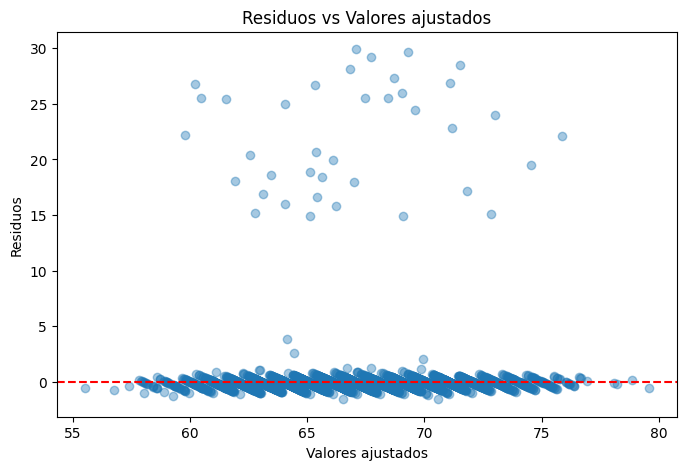

In [ ]:
fitted = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(8, 5))
plt.scatter(fitted, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.title('Residuos vs Valores ajustados')
plt.show()

Según lo observado, habría que agregar términos polinomiales como transformación para atacar este problema. Esto se explorará más adelante en otros modelos.

**Correlación en errores**

In [ ]:
# Correlación entre residuos y variables independientes
correlations = {}
for column in X_train_df.columns:
    correlation = np.corrcoef(model.resid, X_train_df[column])[0, 1]
    correlations[column] = correlation
    print(f"Correlación entre residuos y {column}: {correlation:.4f}")

Correlación entre residuos y num__Hours_Studied: 0.0000
Correlación entre residuos y num__Attendance: -0.0000
Correlación entre residuos y num__Sleep_Hours: -0.0000
Correlación entre residuos y num__Previous_Scores: 0.0000
Correlación entre residuos y num__Tutoring_Sessions: -0.0000
Correlación entre residuos y num__Physical_Activity: -0.0000
Correlación entre residuos y ord__Parental_Involvement: -0.0000
Correlación entre residuos y ord__Access_to_Resources: -0.0000
Correlación entre residuos y ord__Motivation_Level: -0.0000
Correlación entre residuos y ord__Family_Income: -0.0000
Correlación entre residuos y ord__Teacher_Quality: -0.0000
Correlación entre residuos y ord__Peer_Influence: -0.0000
Correlación entre residuos y ord__Parental_Education_Level: -0.0000
Correlación entre residuos y ord__Distance_from_Home: -0.0000
Correlación entre residuos y bin__Extracurricular_Activities: -0.0000
Correlación entre residuos y bin__Internet_Access: -0.0000
Correlación entre residuos y bin__S

**Varianza no constante en residuos (heterocedasticidad)**

In [ ]:
#Test de Breusch-Pagan
test = sms.het_breuschpagan(model.resid, model.model.exog)
print(lzip(['Lagrange multiplier statistic', 'p-value', 'f-value', 'f-p-value'], test))

if test[1] < 0.05:
    print("Se rechaza H0: hay evidencia de heterocedasticidad.")
else:
    print("No se rechaza H0: no hay evidencia de heterocedasticidad.")

[('Lagrange multiplier statistic', np.float64(19.77103361996826)), ('p-value', np.float64(0.4084724845715174)), ('f-value', np.float64(1.0405354398292177)), ('f-p-value', np.float64(0.4088428313770104))]
No se rechaza H0: no hay evidencia de heterocedasticidad.


**Outliers**

In [ ]:
# Outliers con |E|/sigma >= 3
sigma = np.std(model.resid)
outliers = np.where(np.abs(model.resid) / sigma >= 3)[0]
print(f"Índices de valores atípicos: {outliers}")
print(f"Número de outliers: {len(outliers)}")

Índices de valores atípicos: [ 366  468  479  538 1130 1456 1600 1795 1819 1838 2141 2388 2501 2521
 2740 2797 2941 3302 3350 3399 3550 3558 3595 3824 3864 3942 3975 4077
 4128 4213 4327 4377 4560 4779 4847 4852 4905 5263]
Número de outliers: 38


**Puntos palanca**

In [ ]:
# Puntos palanca con hi >= (p+1)/n
influence = model.get_influence()
leverage = influence.hat_matrix_diag
p = X_train_const.shape[1]  # parámetros (incluyendo constante)
n = X_train_const.shape[0]  # observaciones
leverage_threshold = (p + 1) / n
high_leverage = np.where(leverage >= leverage_threshold)[0]
print(f"Índices de puntos palanca: {high_leverage}")
print(f"Número de puntos palanca: {len(high_leverage)}")

Índices de puntos palanca: [   4    7    8 ... 5277 5278 5281]
Número de puntos palanca: 1931


Son observaciones con valores inusuales en los predictores. Se complementará con la distancia de Cook para reducir el número de puntos palanca a eliminar.

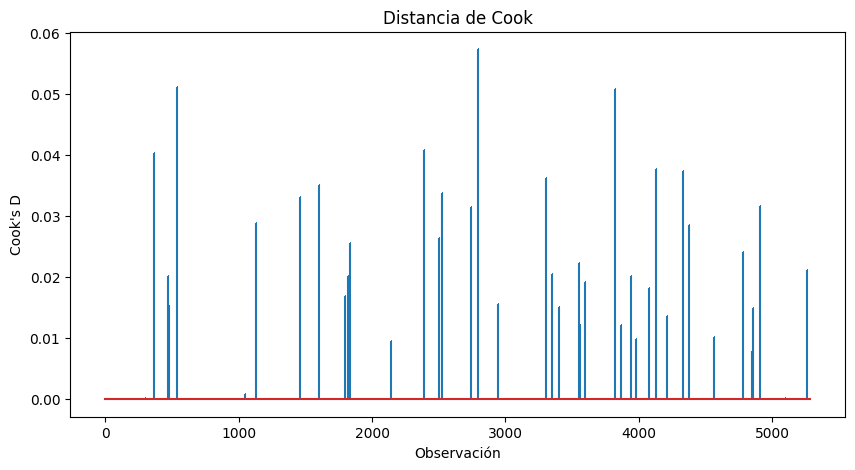

Observaciones influyentes (Cook's D > 4/n): [ 366  468  479  538 1048 1130 1456 1600 1795 1819 1838 2141 2388 2501
 2521 2740 2797 2941 3302 3350 3399 3550 3558 3595 3824 3864 3942 3975
 4077 4128 4213 4327 4377 4560 4779 4847 4852 4905 5263]


In [ ]:
# Distancia de Cook
cooks = influence.cooks_distance[0]
plt.figure(figsize=(10, 5))
plt.stem(np.arange(len(cooks)), cooks, markerfmt=",")
plt.xlabel('Observación')
plt.ylabel("Cook's D")
plt.title("Distancia de Cook")
plt.show()

# Umbral general: 4/n
umbral_cook = 4 / n
influyentes = np.where(cooks > umbral_cook)[0]
print(f"Observaciones influyentes (Cook's D > 4/n): {influyentes}")

**Colinealidad**

In [ ]:
# VIF (Factor de Inflación de Varianza)
vif_data = pd.DataFrame()
vif_data["feature"] = X_train_df.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_df.values, i)
                   for i in range(X_train_df.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

                            feature       VIF
15             bin__Internet_Access  8.344209
10             ord__Teacher_Quality  4.410450
7          ord__Access_to_Resources  3.232763
11              ord__Peer_Influence  3.232372
6         ord__Parental_Involvement  3.228069
8             ord__Motivation_Level  2.591776
14  bin__Extracurricular_Activities  2.366728
18                      bin__Gender  2.301970
9                ord__Family_Income  2.054087
12    ord__Parental_Education_Level  1.761414
13          ord__Distance_from_Home  1.540030
16                 bin__School_Type  1.427957
17       bin__Learning_Disabilities  1.119385
3              num__Previous_Scores  1.004983
5            num__Physical_Activity  1.004777
1                   num__Attendance  1.003637
0                num__Hours_Studied  1.003024
4            num__Tutoring_Sessions  1.002428
2                  num__Sleep_Hours  1.002113


VIF > 10 indica colinealidad severa. VIF > 5 es moderada. Si hay colinealidad, Ridge y ElasticNet son las alternativas más estables.

#### 4.1.6 Transformación y Ajuste

Eliminar outliers y puntos palanca (solo los de Cook, ya que los puntos palanca normales son muchos)

In [ ]:
idx_eliminar = np.unique(np.concatenate([outliers, influyentes]))

X_train_filt = X_train_const.drop(X_train_const.index[idx_eliminar])
y_train_filt = y_train.drop(y_train.index[idx_eliminar])

In [ ]:
model_filt = sm.OLS(y_train_filt, X_train_filt).fit()
print(model_filt.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                 2.826e+04
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:39:10   Log-Likelihood:                -1634.4
No. Observations:                5243   AIC:                             3309.
Df Residuals:                    5223   BIC:                             3440.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

### 4.1.7 Ajuste de versiones y R2

In [ ]:
# Ajustar OLS
pipeline_base.fit(X_train, y_train)

# Ajustar Ridge con GridSearch
grid_ridge = GridSearchCV(
    pipeline_ridge,
    {'model__alpha': np.logspace(-3, 3, 50)},
    cv=5, scoring='r2', n_jobs=-1
)
grid_ridge.fit(X_train, y_train)
best_ridge = grid_ridge.best_estimator_

# Ajustar Lasso con GridSearch
grid_lasso = GridSearchCV(
    pipeline_lasso,
    {'model__alpha': np.logspace(-3, 1, 50)},
    cv=5, scoring='r2', n_jobs=-1
)
grid_lasso.fit(X_train, y_train)
best_lasso = grid_lasso.best_estimator_

# Ajustar ElasticNet con GridSearch
grid_enet = GridSearchCV(
    pipeline_enet,
    {'model__alpha': np.logspace(-3, 1, 20),
     'model__l1_ratio': np.linspace(0.1, 0.9, 9)},
    cv=5, scoring='r2', n_jobs=-1
)
grid_enet.fit(X_train, y_train)
best_enet = grid_enet.best_estimator_

#Dataframe para comparar
modelos = {
    'OLS': pipeline_base,
    'Ridge': best_ridge,
    'Lasso': best_lasso,
    'ElasticNet': best_enet
}

filas = []
for nombre, modelo in modelos.items():
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    filas.append({
        'Modelo': nombre,
        'R2_train': r2_score(y_train, y_train_pred),
        'R2_test': r2_score(y_test, y_test_pred),
        'RMSE_train': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'RMSE_test': np.sqrt(mean_squared_error(y_test, y_test_pred))
    })

df_resultados = pd.DataFrame(filas).set_index('Modelo')
print(df_resultados.round(4))

            R2_train  R2_test  RMSE_train  RMSE_test
Modelo                                              
OLS           0.7457   0.6700      1.9501     2.2268
Ridge         0.7457   0.6703      1.9501     2.2258
Lasso         0.7456   0.6707      1.9502     2.2242
ElasticNet    0.7456   0.6706      1.9502     2.2247


In [ ]:

# from IPython.display import display, HTML
# from sklearn import set_config

# set_config(display='diagram')

# display(HTML("<h3>OLS (ajustado)</h3>"))
# display(pipeline_base)

# display(HTML("<h3>Ridge (ajustado)</h3>"))
# display(best_ridge)

# display(HTML("<h3>Lasso (ajustado)</h3>"))
# display(best_lasso)

# display(HTML("<h3>ElasticNet (ajustado)</h3>"))
# display(best_enet)

#### 4.1.8 Compración de métricas

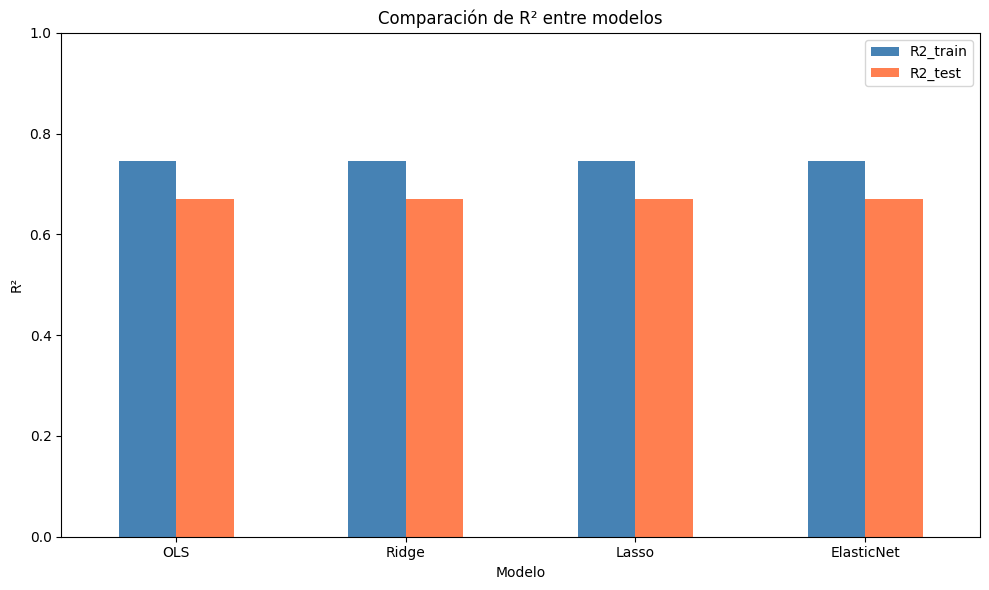

In [ ]:
df_resultados[['R2_train', 'R2_test']].plot(kind='bar', figsize=(10, 6), color=['steelblue', 'coral'])
plt.title('Comparación de R² entre modelos')
plt.ylabel('R²')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

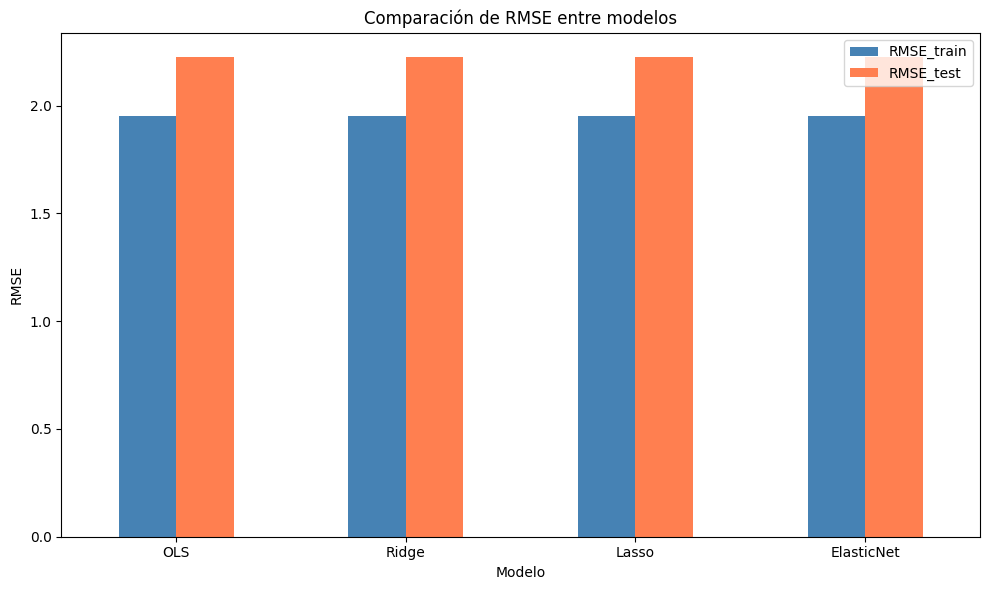

In [ ]:
df_resultados[['RMSE_train', 'RMSE_test']].plot(kind='bar', figsize=(10, 6), color=['steelblue', 'coral'])
plt.title('Comparación de RMSE entre modelos')
plt.ylabel('RMSE')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### 4.1.9 Observaciones de interés

No hay sobreajuste severo. Si lo hubiera, Ridge/Lasso/ElasticNet reducirían la brecha train-test. No lo hacen, así que el OLS ya está bien.
No hay colinealidad problemática. Si la hubiera, Ridge y ElasticNet mejorarían notablemente al OLS. No lo hacen.
El alpha óptimo probablemente sea muy pequeño. GridSearchCV seguramente eligió valores cercanos a 0, lo que equivale a "no penalizar". Eso confirma que la penalización no ayuda para este modelo inicial.

El modelo lineal sin interacciones es suficiente para este dataset. Los modelos polinomial y con interacciones desarrollados en la siguiente sección buscarán mejorar esto, de no ser así, la conclusión general será que la relación es esencialmente lineal.

#### 4.1.10 Análisis de significancia de factores (modelo lineal sin penalización)

Se ajustó una regresión lineal múltiple por mínimos cuadrados ordinarios (OLS) sobre el conjunto de entrenamiento, tras eliminar las observaciones identificadas como outliers y puntos influyentes según la distancia de Cook.

**Factores significativos (p < 0.05):** 17 de 19 factores resultaron significativos. Los de mayor magnitud positiva son `Attendance` (+2.32), `Hours_Studied` (+1.79), `Internet_Access` (+1.01) y `Access_to_Resources` (+1.00). Los de mayor magnitud negativa son `Learning_Disabilities` (−1.03) y `Distance_from_Home` (−0.50).

**Factores no significativos (p ≥ 0.05):** `School_Type` (p = 0.783) y `Gender` (p = 0.481) no mostraron evidencia de asociación con `Exam_Score` al 5% de significancia, controlando por los demás factores del modelo.

Sobre `Sleep_Hours` aunque resultó significativo (p < 0.001), su coeficiente es prácticamente nulo (+0.0236). Esto es porque la significancia estadística no implica relevancia práctica, especialmente con tamaños de muestra grandes.

**Prueba F global:** El estadístico F del modelo es altamente significativo (p < 0.001), lo que indica que al menos uno de los coeficientes de pendiente es distinto de cero. El modelo en su conjunto explica una proporción considerable de la variabilidad de `Exam_Score`.

Las magnitudes de los coeficientes presentan valores uniformes (±0.5, ±1.0) y errores estándar extremadamente pequeños, esto se debe a que el dataset es sintético.

### 4.2 Regresión lineal multiple polinomial

#### 4.2.1 Justifiación

#### 4.2.2 Versiones a comparar


| Versión | Método | Penalización |
|---|---|---|
| Base | `LinearRegression` | Ninguna |
| Ridge | `Ridge` | $L_2$ |
| Lasso | `Lasso` | $L_1$ |
| ElasticNet | `ElasticNet` | $L_1 + L_2$ |

Para Ridge, Lasso y ElasticNet, el hiperparámetro de penalización se seleccionará mediante validación cruzada de 5 folds sobre el conjunto de entrenamiento, usando `GridSearchCV` y `R²` como métrica.

#### 4.2.3 Pipelines
Antes de crear los pipelines, se añade los factores nuevos para ahora si definir los pipelines

In [ ]:
df_pol = df.copy()
df_pol['Tutoring_Sessions_Sq'] = df_pol['Tutoring_Sessions'] ** 2
df_pol = df_pol.drop(columns=['Tutoring_Sessions'])

num_cols_pol = num_cols + ['Tutoring_Sessions_Sq']
num_cols_pol.remove('Tutoring_Sessions')
ord_cols_pol = ord_cols
bin_cols_pol = bin_cols

ordinal_categories_pol = ordinal_categories
binary_categories_pol = binary_categories

numerical_transformer_pol = Pipeline(steps=[('scaler', StandardScaler())])
ordinal_transformer_pol = Pipeline(steps=[('encoder', OrdinalEncoder(categories=ordinal_categories_pol))])
binary_transformer_pol = Pipeline(steps=[('encoder', OrdinalEncoder(categories=binary_categories_pol))])

preprocessor_pol = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_pol, num_cols_pol),
        ('ord', ordinal_transformer_pol, ord_cols_pol),
        ('bin', binary_transformer_pol, bin_cols_pol)
    ]
)



In [ ]:
pipeline_base_pol = Pipeline(
    steps=[('preprocessor', preprocessor_pol),
           ('model', LinearRegression())]
)

pipeline_ridge_pol = Pipeline(
    steps=[('preprocessor', preprocessor_pol),
           ('model', Ridge(random_state=123))]
)

pipeline_lasso_pol = Pipeline(
    steps=[('preprocessor', preprocessor_pol),
           ('model', Lasso(random_state=123, max_iter=10000))]
)

pipeline_enet_pol = Pipeline(
    steps=[('preprocessor', preprocessor_pol),
           ('model', ElasticNet(random_state=123, max_iter=10000))]
)

Despues de iterar con una variedad de nuevos factores de diferentes potencias, el mejor resultado fue únicamente elevar al cuadrado `Tutoring_Sessions`, por el momento se piensa que el mejor modelo entre estos dos es el modelo baseline.

#### 4.2.4 Ajuste modelos sin penalización

In [ ]:
X_pol = df_pol.drop(columns=target_col)
y_pol = df_pol[target_col]

X_train_pol, X_test_pol, y_train_pol, y_test_pol = train_test_split(
    X_pol, y_pol, test_size=0.2, random_state=123
)

preprocessor_pol.fit(X_train_pol)

X_train_pol_trans = preprocessor_pol.transform(X_train_pol)
X_test_pol_trans = preprocessor_pol.transform(X_test_pol)

feature_names_pol = preprocessor_pol.get_feature_names_out()

X_train_pol_df = pd.DataFrame(
    X_train_pol_trans,
    columns=feature_names_pol,
    index=X_train_pol.index
)

X_train_pol_const = sm.add_constant(X_train_pol_df, has_constant='add')

model_pol = sm.OLS(y_train_pol, X_train_pol_const).fit()

print(model_pol.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     793.6
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:39:39   Log-Likelihood:                -10982.
No. Observations:                5282   AIC:                         2.200e+04
Df Residuals:                    5262   BIC:                         2.214e+04
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

#### 4.2.5 Análisis de residuos

**No linealidad**

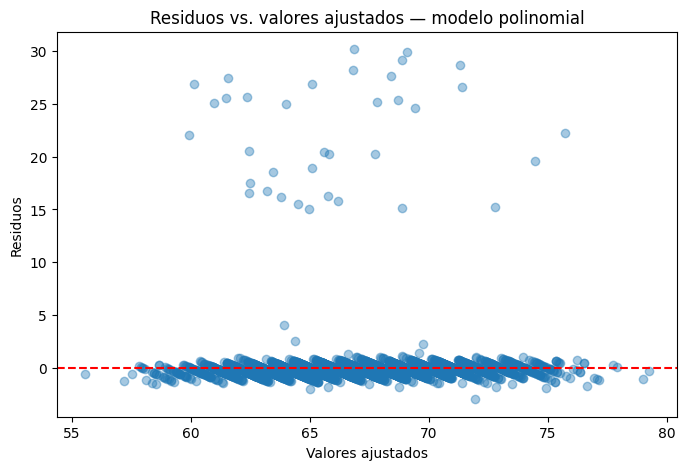

In [ ]:
fitted_pol = model_pol.fittedvalues
residuals_pol = model_pol.resid

plt.figure(figsize=(8, 5))
plt.scatter(fitted_pol, residuals_pol, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.title('Residuos vs. valores ajustados — modelo polinomial')
plt.show()

**Correlación en errores**

In [ ]:
correlations_pol = {}

for column in X_train_pol_df.columns:
    correlation = np.corrcoef(model_pol.resid, X_train_pol_df[column])[0, 1]
    correlations_pol[column] = correlation
    print(f'Correlación entre residuos y {column}: {correlation:.4f}')

Correlación entre residuos y num__Hours_Studied: -0.0000
Correlación entre residuos y num__Attendance: 0.0000
Correlación entre residuos y num__Sleep_Hours: 0.0000
Correlación entre residuos y num__Previous_Scores: 0.0000
Correlación entre residuos y num__Physical_Activity: 0.0000
Correlación entre residuos y num__Tutoring_Sessions_Sq: 0.0000
Correlación entre residuos y ord__Parental_Involvement: -0.0000
Correlación entre residuos y ord__Access_to_Resources: -0.0000
Correlación entre residuos y ord__Motivation_Level: -0.0000
Correlación entre residuos y ord__Family_Income: -0.0000
Correlación entre residuos y ord__Teacher_Quality: -0.0000
Correlación entre residuos y ord__Peer_Influence: -0.0000
Correlación entre residuos y ord__Parental_Education_Level: -0.0000
Correlación entre residuos y ord__Distance_from_Home: -0.0000
Correlación entre residuos y bin__Extracurricular_Activities: -0.0000
Correlación entre residuos y bin__Internet_Access: -0.0000
Correlación entre residuos y bin__S

**Varianza no constante en residuos**

In [ ]:
test_bp_pol = sms.het_breuschpagan(
    model_pol.resid,
    model_pol.model.exog
)

print(lzip(
    ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value'],
    test_bp_pol
))

if test_bp_pol[1] < 0.05:
    print('Se rechaza H₀: hay evidencia de heterocedasticidad.')
else:
    print('No se rechaza H₀: no hay evidencia de heterocedasticidad.')

[('Lagrange multiplier statistic', np.float64(20.31267497687865)), ('p-value', np.float64(0.3759883826237864)), ('f-value', np.float64(1.0691516870805307)), ('f p-value', np.float64(0.37629222917177596))]
No se rechaza H₀: no hay evidencia de heterocedasticidad.


**Outliers**

In [ ]:
sigma_pol = np.std(model_pol.resid)

outliers_pol = np.where(
    np.abs(model_pol.resid) / sigma_pol >= 3
)[0]

print(f'Índices de valores atípicos: {outliers_pol}')
print(f'Número de outliers: {len(outliers_pol)}')

Índices de valores atípicos: [ 196  290  329  422  490  515  720  722  871 1046 1090 1100 1109 1211
 1216 1244 1373 1382 1456 1646 1709 2220 2775 2791 3178 3289 3643 3907
 3952 4248 4302 4306 4315 4512 5088 5094]
Número de outliers: 36


**Puntos palanca y distancia de Cook**

Índices de puntos palanca: [   3    7    8 ... 5276 5279 5281]
Número de puntos palanca: 1856


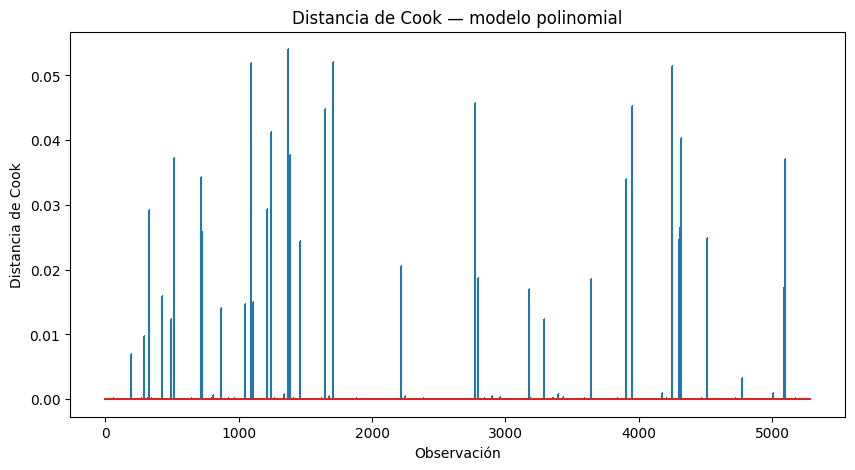

Observaciones influyentes (Cook’s D > 0.00076): [ 196  290  329  422  490  515  720  722  871 1046 1090 1100 1109 1211
 1216 1244 1339 1373 1382 1456 1646 1709 2220 2775 2791 3178 3289 3393
 3643 3907 3952 4175 4248 4302 4306 4315 4512 4771 5008 5088 5094]


In [ ]:
influence_pol = model_pol.get_influence()

leverage_pol = influence_pol.hat_matrix_diag
p_pol = X_train_pol_const.shape[1]
n_pol = X_train_pol_const.shape[0]

leverage_threshold_pol = (p_pol + 1) / n_pol

high_leverage_pol = np.where(
    leverage_pol >= leverage_threshold_pol
)[0]

print(f'Índices de puntos palanca: {high_leverage_pol}')
print(f'Número de puntos palanca: {len(high_leverage_pol)}')

cooks_pol = influence_pol.cooks_distance[0]

plt.figure(figsize=(10, 5))
plt.stem(np.arange(len(cooks_pol)), cooks_pol, markerfmt=',')
plt.xlabel('Observación')
plt.ylabel("Distancia de Cook")
plt.title('Distancia de Cook — modelo polinomial')
plt.show()

umbral_cook_pol = 4 / n_pol

influyentes_pol = np.where(
    cooks_pol > umbral_cook_pol
)[0]

print(
    'Observaciones influyentes '
    f'(Cook’s D > {umbral_cook_pol:.5f}): {influyentes_pol}'
)

**Colinealidad**

In [ ]:
vif_data_pol = pd.DataFrame()

vif_data_pol['feature'] = X_train_pol_df.columns
vif_data_pol['VIF'] = [
    variance_inflation_factor(X_train_pol_df.values, i)
    for i in range(X_train_pol_df.shape[1])
]

print(vif_data_pol.sort_values('VIF', ascending=False))

                            feature       VIF
15             bin__Internet_Access  8.396183
10             ord__Teacher_Quality  4.416866
11              ord__Peer_Influence  3.240875
6         ord__Parental_Involvement  3.165074
7          ord__Access_to_Resources  3.128922
8             ord__Motivation_Level  2.589934
14  bin__Extracurricular_Activities  2.336054
18                      bin__Gender  2.288757
9                ord__Family_Income  2.066324
12    ord__Parental_Education_Level  1.761636
13          ord__Distance_from_Home  1.531177
16                 bin__School_Type  1.425968
17       bin__Learning_Disabilities  1.114676
2                  num__Sleep_Hours  1.003868
3              num__Previous_Scores  1.003809
1                   num__Attendance  1.003638
4            num__Physical_Activity  1.003638
5         num__Tutoring_Sessions_Sq  1.003271
0                num__Hours_Studied  1.002528


#### 4.2.6 Transformación y ajuste

Se eliminan únicamente las observaciones identificadas como outliers o influyentes mediante la distancia de Cook. Posteriormente, se ajusta nuevamente el modelo OLS para revisar sus coeficientes y supuestos.

In [ ]:
idx_eliminar_pol = np.unique(
    np.concatenate([outliers_pol, influyentes_pol])
)

X_train_pol_filt = X_train_pol_const.drop(
    X_train_pol_const.index[idx_eliminar_pol]
)

y_train_pol_filt = y_train_pol.drop(
    y_train_pol.index[idx_eliminar_pol]
)

model_pol_filt = sm.OLS(
    y_train_pol_filt,
    X_train_pol_filt
).fit()

print(model_pol_filt.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                 1.802e+04
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:39:39   Log-Likelihood:                -2765.5
No. Observations:                5241   AIC:                             5571.
Df Residuals:                    5221   BIC:                             5702.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

#### 4.2.7 Ajuste de versiones y R²

Se ajustan las versiones OLS, Ridge, Lasso y ElasticNet. Los hiperparámetros de penalización se seleccionan con validación cruzada de cinco folds y R² como métrica.

In [ ]:
pipeline_base_pol.fit(X_train_pol, y_train_pol)

grid_ridge_pol = GridSearchCV(
    pipeline_ridge_pol,
    {'model__alpha': np.logspace(-3, 3, 50)},
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_ridge_pol.fit(X_train_pol, y_train_pol)
best_ridge_pol = grid_ridge_pol.best_estimator_

grid_lasso_pol = GridSearchCV(
    pipeline_lasso_pol,
    {'model__alpha': np.logspace(-3, 1, 50)},
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_lasso_pol.fit(X_train_pol, y_train_pol)
best_lasso_pol = grid_lasso_pol.best_estimator_

grid_enet_pol = GridSearchCV(
    pipeline_enet_pol,
    {
        'model__alpha': np.logspace(-3, 1, 20),
        'model__l1_ratio': np.linspace(0.1, 0.9, 9)
    },
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_enet_pol.fit(X_train_pol, y_train_pol)
best_enet_pol = grid_enet_pol.best_estimator_

modelos_pol = {
    'OLS_polinomial': pipeline_base_pol,
    'Ridge_polinomial': best_ridge_pol,
    'Lasso_polinomial': best_lasso_pol,
    'ElasticNet_polinomial': best_enet_pol
}

filas_pol = []

for nombre, modelo in modelos_pol.items():
    y_train_pred_pol = modelo.predict(X_train_pol)
    y_test_pred_pol = modelo.predict(X_test_pol)

    filas_pol.append({
        'Modelo': nombre,
        'R2_train': r2_score(y_train_pol, y_train_pred_pol),
        'R2_test': r2_score(y_test_pol, y_test_pred_pol),
        'RMSE_train': np.sqrt(
            mean_squared_error(y_train_pol, y_train_pred_pol)
        ),
        'RMSE_test': np.sqrt(
            mean_squared_error(y_test_pol, y_test_pred_pol)
        )
    })

df_resultados_pol = pd.DataFrame(filas_pol).set_index('Modelo')

print(df_resultados_pol.round(4))

                       R2_train  R2_test  RMSE_train  RMSE_test
Modelo                                                         
OLS_polinomial           0.7413   0.6742      1.9352     2.3481
Ridge_polinomial         0.7413   0.6742      1.9352     2.3481
Lasso_polinomial         0.7413   0.6743      1.9353     2.3481
ElasticNet_polinomial    0.7413   0.6742      1.9353     2.3481


#### 4.2.8 Comparación de Metricas

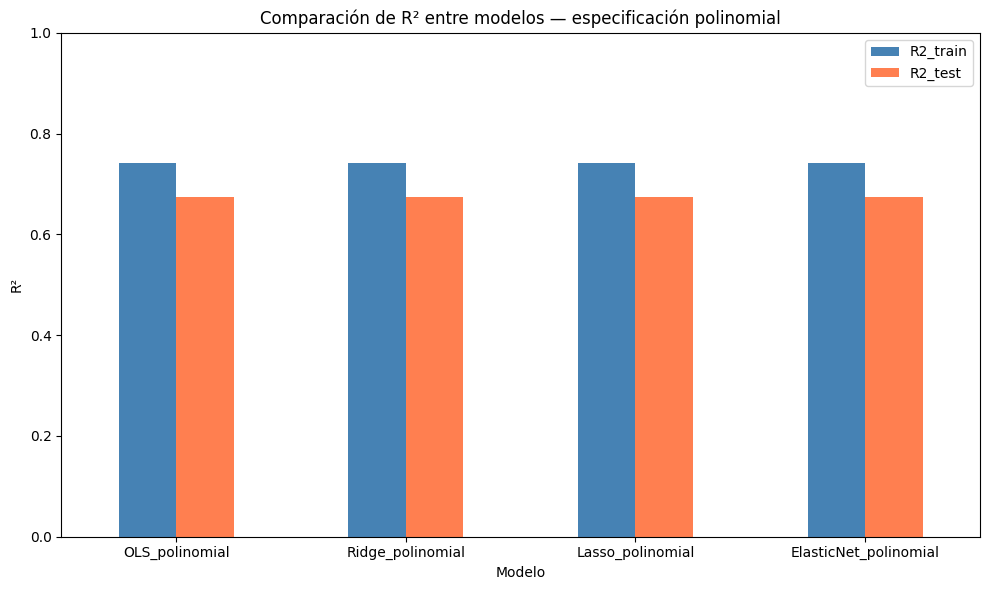

In [ ]:
df_resultados_pol[['R2_train', 'R2_test']].plot(
    kind='bar',
    figsize=(10, 6),
    color=['steelblue', 'coral']
)

plt.title('Comparación de R² entre modelos — especificación polinomial')
plt.ylabel('R²')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### 4.2.9 Observaciones de interés

La evaluación de las potencias de las variables numéricas no mostró una mejora estable del R² fuera de muestra, es decir que el modelo polinomial nunca va a superar al modelo lineal en este dataset, es importante mencionar que el uso de Ridge, Lasso y Elstic Net no tuvo ningun efecto al igual que el modelo pasado. Así mismo el modelo despues del análisis de residuos parace tener una $R^2$ sumamente buena, lo que pareciera que el dataset esta diseñado para que este sea el caso.

#### 4.2.10 Análisis de significancia de factores

Se analiza la significancia individual de los factores mediante pruebas t y la significancia global mediante la prueba F del modelo OLS ajustado después de retirar las observaciones atípicas e influyentes.

In [ ]:
tabla_significancia_pol = pd.DataFrame({
    'Factor': model_pol_filt.params.index,
    'Coeficiente': model_pol_filt.params.values,
    'Error_estandar': model_pol_filt.bse.values,
    't': model_pol_filt.tvalues.values,
    'p_valor': model_pol_filt.pvalues.values
})

tabla_significancia_pol['Significativo_5%'] = np.where( tabla_significancia_pol['p_valor'] < 0.05, 'Sí', 'No' )
tabla_significancia_pol = tabla_significancia_pol.sort_values('p_valor')

display(tabla_significancia_pol)

,Factor,Coeficiente,Error_estandar,t,p_valor,Significativo_5%
0,const,61.658065,0.032119,1919.704615,0.000000,Sí
1,num__Hours_Studied,1.782830,0.005694,313.125009,0.000000,Sí
2,num__Attendance,2.304657,0.005685,405.400323,0.000000,Sí
4,num__Previous_Scores,0.709270,0.005690,124.657814,0.000000,Sí
6,num__Tutoring_Sessions_Sq,0.578029,0.005863,98.595640,0.000000,Sí
5,num__Physical_Activity,0.234983,0.005692,41.279349,0.000000,Sí
7,ord__Parental_Involvement,0.991769,0.008195,121.016832,0.000000,Sí
8,ord__Access_to_Resources,0.989732,0.008122,121.862443,0.000000,Sí
12,ord__Peer_Influence,0.508265,0.007531,67.485934,0.000000,Sí
9,ord__Motivation_Level,0.508254,0.008175,62.168476,0.000000,Sí


### 4.3 Regresión lineal con interacciones

#### 4.3.1 Justificación

Se propone un tercer modelo que incorpora interacciones justificadas entre factores académicos y de contexto, manteniendo los efectos principales originales (principio jerárquico). Las interacciones seleccionadas son:

- `Hours_Studied × Tutoring_Sessions`: el efecto de las horas de estudio podría depender de las sesiones de tutoría recibidas.
- `Hours_Studied × Access_to_Resources`: estudiar puede rendir más cuando hay buen acceso a recursos educativos.
- `Attendance × Parental_Involvement`: el efecto de la asistencia sobre la calificación podría variar según la participación de los padres.
- `Previous_Scores × Motivation_Level`: el desempeño previo podría pesar de forma distinta según el nivel de motivación actual.

Se mantiene el mismo esquema de preprocesamiento y las mismas cuatro versiones (OLS, Ridge, Lasso, ElasticNet) que en el modelo inicial, para que la comparación sea consistente.

#### 4.3.2 Versiones a comparar


| Versión | Método | Penalización |
|---|---|---|
| Base | `LinearRegression` | Ninguna |
| Ridge | `Ridge` | $L_2$ |
| Lasso | `Lasso` | $L_1$ |
| ElasticNet | `ElasticNet` | $L_1 + L_2$ |

Para Ridge, Lasso y ElasticNet, el hiperparámetro de penalización se seleccionará mediante validación cruzada de 5 folds sobre el conjunto de entrenamiento, usando `GridSearchCV` y `R²` como métrica.

#### 4.3.3 Variables de interacción y pipelines

Las interacciones se construyen conservando todos los efectos principales, de acuerdo con el principio jerárquico. Las variables ordinales utilizadas en productos se codifican temporalmente como 0, 1 y 2; estas columnas auxiliares se eliminan antes del preprocesamiento.

In [ ]:
df_int = df.copy()

nivel_map = {'Low': 0, 'Medium': 1, 'High': 2}

df_int['Access_num'] = df_int['Access_to_Resources'].map(nivel_map)
df_int['Motivation_num'] = df_int['Motivation_Level'].map(nivel_map)
df_int['Parental_num'] = df_int['Parental_Involvement'].map(nivel_map)

df_int['Hours_x_Tutoring'] = (
    df_int['Hours_Studied'] * df_int['Tutoring_Sessions']
)
df_int['Hours_x_Access'] = (
    df_int['Hours_Studied'] * df_int['Access_num']
)
df_int['Attendance_x_Parental'] = (
    df_int['Attendance'] * df_int['Parental_num']
)
df_int['PrevScores_x_Motivation'] = (
    df_int['Previous_Scores'] * df_int['Motivation_num']
)

df_int = df_int.drop(
    columns=['Access_num', 'Motivation_num', 'Parental_num']
)

interacciones = [
    'Hours_x_Tutoring',
    'Hours_x_Access',
    'Attendance_x_Parental',
    'PrevScores_x_Motivation'
]

num_cols_int = num_cols.copy() + interacciones
ord_cols_int = ord_cols.copy()
bin_cols_int = bin_cols.copy()

In [ ]:
numerical_transformer_int = Pipeline(
    steps=[('scaler', StandardScaler())]
)

ordinal_transformer_int = Pipeline(
    steps=[('encoder', OrdinalEncoder(categories=ordinal_categories))]
)

binary_transformer_int = Pipeline(
    steps=[('encoder', OrdinalEncoder(categories=binary_categories))]
)

preprocessor_int = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_int, num_cols_int),
        ('ord', ordinal_transformer_int, ord_cols_int),
        ('bin', binary_transformer_int, bin_cols_int)
    ]
)

pipeline_base_int = Pipeline(
    steps=[('preprocessor', preprocessor_int),
           ('model', LinearRegression())]
)

pipeline_ridge_int = Pipeline(
    steps=[('preprocessor', preprocessor_int),
           ('model', Ridge(random_state=42))]
)

pipeline_lasso_int = Pipeline(
    steps=[('preprocessor', preprocessor_int),
           ('model', Lasso(random_state=42, max_iter=10000))]
)

pipeline_enet_int = Pipeline(
    steps=[('preprocessor', preprocessor_int),
           ('model', ElasticNet(random_state=42, max_iter=10000))]
)

#### 4.3.4 Ajuste del modelo sin penalización

Se ajusta un modelo OLS con los efectos principales y las cuatro interacciones propuestas. Se utiliza la misma partición de entrenamiento y prueba de las secciones anteriores para mantener una comparación consistente.

In [ ]:
X_int = df_int.drop(columns=target_col)
y_int = df_int[target_col]

X_train_int, X_test_int, y_train_int, y_test_int = train_test_split(
    X_int, y_int, test_size=0.2, random_state=42
)

preprocessor_int.fit(X_train_int)

X_train_int_trans = preprocessor_int.transform(X_train_int)
X_test_int_trans = preprocessor_int.transform(X_test_int)

feature_names_int = preprocessor_int.get_feature_names_out()

X_train_int_df = pd.DataFrame(
    X_train_int_trans,
    columns=feature_names_int,
    index=X_train_int.index
)

X_train_int_const = sm.add_constant(X_train_int_df, has_constant='add')

model_int = sm.OLS(y_train_int, X_train_int_const).fit()

print(model_int.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     671.1
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:39:55   Log-Likelihood:                -11020.
No. Observations:                5282   AIC:                         2.209e+04
Df Residuals:                    5258   BIC:                         2.225e+04
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

#### 4.3.5 Análisis de residuos

Se verifican los supuestos del modelo mediante residuos, correlaciones con los predictores, prueba de Breusch-Pagan, outliers, puntos palanca, distancia de Cook y VIF.

**No linealidad**

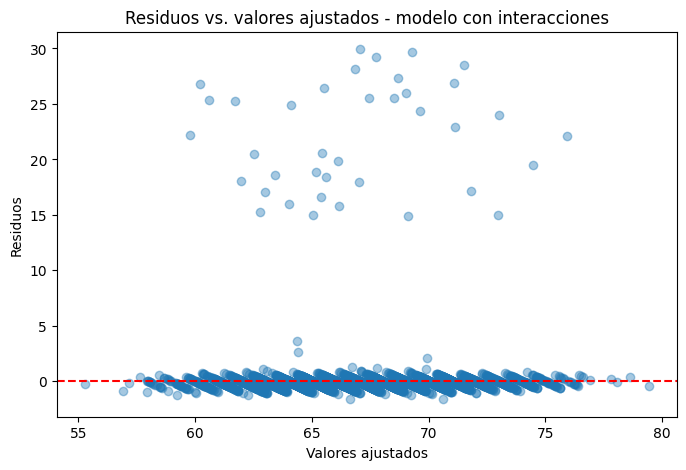

In [ ]:
fitted_int = model_int.fittedvalues
residuals_int = model_int.resid

plt.figure(figsize=(8, 5))
plt.scatter(fitted_int, residuals_int, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.title('Residuos vs. valores ajustados - modelo con interacciones')
plt.show()

**Correlación en errores**

In [ ]:
correlations_int = {}

for column in X_train_int_df.columns:
    correlation = np.corrcoef(model_int.resid, X_train_int_df[column])[0, 1]
    correlations_int[column] = correlation
    print(f'Correlación entre residuos y {column}: {correlation:.4f}')

Correlación entre residuos y num__Hours_Studied: 0.0000
Correlación entre residuos y num__Attendance: -0.0000
Correlación entre residuos y num__Sleep_Hours: -0.0000
Correlación entre residuos y num__Previous_Scores: -0.0000
Correlación entre residuos y num__Tutoring_Sessions: 0.0000
Correlación entre residuos y num__Physical_Activity: -0.0000
Correlación entre residuos y num__Hours_x_Tutoring: 0.0000
Correlación entre residuos y num__Hours_x_Access: 0.0000
Correlación entre residuos y num__Attendance_x_Parental: 0.0000
Correlación entre residuos y num__PrevScores_x_Motivation: 0.0000
Correlación entre residuos y ord__Parental_Involvement: 0.0000
Correlación entre residuos y ord__Access_to_Resources: 0.0000
Correlación entre residuos y ord__Motivation_Level: 0.0000
Correlación entre residuos y ord__Family_Income: 0.0000
Correlación entre residuos y ord__Teacher_Quality: 0.0000
Correlación entre residuos y ord__Peer_Influence: -0.0000
Correlación entre residuos y ord__Parental_Education_

**Varianza no constante en residuos**

In [ ]:
test_bp_int = sms.het_breuschpagan(
    model_int.resid,
    model_int.model.exog
)

print(lzip(
    ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value'],
    test_bp_int
))

if test_bp_int[1] < 0.05:
    print('Se rechaza H0: hay evidencia de heterocedasticidad.')
else:
    print('No se rechaza H0: no hay evidencia de heterocedasticidad.')

[('Lagrange multiplier statistic', np.float64(25.082203605705907)), ('p-value', np.float64(0.3460608541347617)), ('f-value', np.float64(1.090755091189671)), ('f p-value', np.float64(0.3462942811997459))]
No se rechaza H0: no hay evidencia de heterocedasticidad.


**Outliers**

In [ ]:
sigma_int = np.std(model_int.resid)

outliers_int = np.where(
    np.abs(model_int.resid) / sigma_int >= 3
)[0]

print(f'Índices de valores atípicos: {outliers_int}')
print(f'Número de outliers: {len(outliers_int)}')

Índices de valores atípicos: [ 366  468  479  538 1130 1456 1600 1795 1819 1838 2141 2388 2501 2521
 2740 2797 2941 3302 3350 3399 3550 3558 3595 3824 3864 3942 3975 4077
 4128 4213 4327 4377 4560 4779 4847 4852 4905 5263]
Número de outliers: 38


**Puntos palanca y distancia de Cook**

Índices de puntos palanca: [   7    8   12 ... 5277 5278 5281]
Número de puntos palanca: 2007


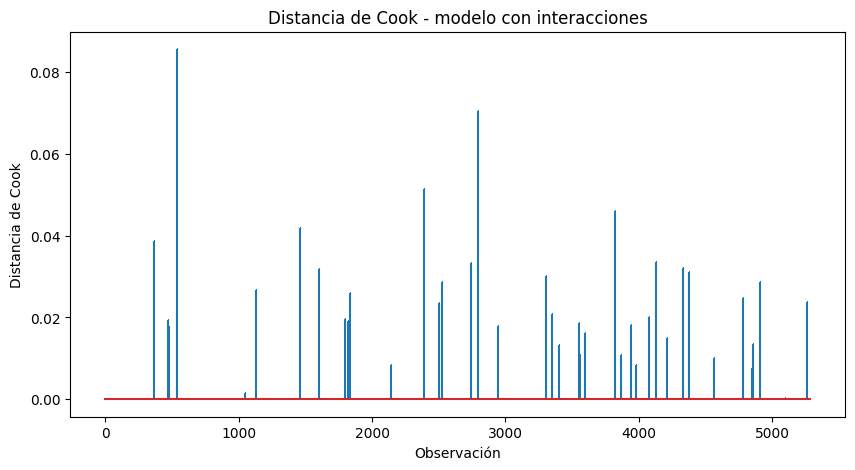

Observaciones influyentes (Cook D > 0.00076): [ 366  468  479  538 1048 1130 1456 1600 1795 1819 1838 2141 2388 2501
 2521 2740 2797 2941 3302 3350 3399 3550 3558 3595 3824 3864 3942 3975
 4077 4128 4213 4327 4377 4560 4779 4847 4852 4905 5263]


In [ ]:
influence_int = model_int.get_influence()

leverage_int = influence_int.hat_matrix_diag
p_int = X_train_int_const.shape[1]
n_int = X_train_int_const.shape[0]

leverage_threshold_int = (p_int + 1) / n_int

high_leverage_int = np.where(
    leverage_int >= leverage_threshold_int
)[0]

print(f'Índices de puntos palanca: {high_leverage_int}')
print(f'Número de puntos palanca: {len(high_leverage_int)}')

cooks_int = influence_int.cooks_distance[0]

plt.figure(figsize=(10, 5))
plt.stem(np.arange(len(cooks_int)), cooks_int, markerfmt=',')
plt.xlabel('Observación')
plt.ylabel('Distancia de Cook')
plt.title('Distancia de Cook - modelo con interacciones')
plt.show()

umbral_cook_int = 4 / n_int

influyentes_int = np.where(
    cooks_int > umbral_cook_int
)[0]

print(
    'Observaciones influyentes '
    f'(Cook D > {umbral_cook_int:.5f}): {influyentes_int}'
)

**Colinealidad**

In [ ]:
vif_data_int = pd.DataFrame()

vif_data_int['feature'] = X_train_int_df.columns
vif_data_int['VIF'] = [
    variance_inflation_factor(X_train_int_df.values, i)
    for i in range(X_train_int_df.shape[1])
]

print(vif_data_int.sort_values('VIF', ascending=False))

                            feature        VIF
10        ord__Parental_Involvement  77.943250
12            ord__Motivation_Level  59.890933
11         ord__Access_to_Resources  37.166877
8        num__Attendance_x_Parental  23.887743
9      num__PrevScores_x_Motivation  23.675661
6             num__Hours_x_Tutoring  13.398523
7               num__Hours_x_Access  12.939739
19             bin__Internet_Access  12.653434
4            num__Tutoring_Sessions  11.977614
14             ord__Teacher_Quality   4.905236
0                num__Hours_Studied   4.846975
15              ord__Peer_Influence   3.508974
18  bin__Extracurricular_Activities   2.453247
22                      bin__Gender   2.387002
3              num__Previous_Scores   2.343135
1                   num__Attendance   2.154046
13               ord__Family_Income   2.117645
16    ord__Parental_Education_Level   1.802228
17          ord__Distance_from_Home   1.565279
20                 bin__School_Type   1.443525
21       bin_

#### 4.3.6 Transformación y ajuste

Se eliminan únicamente las observaciones detectadas como outliers o influyentes mediante la distancia de Cook. Con los datos filtrados se vuelve a estimar el modelo OLS.

In [ ]:
idx_eliminar_int = np.unique(
    np.concatenate([outliers_int, influyentes_int])
)

X_train_int_filt = X_train_int_const.drop(
    X_train_int_const.index[idx_eliminar_int]
)

y_train_int_filt = y_train_int.drop(
    y_train_int.index[idx_eliminar_int]
)

model_int_filt = sm.OLS(
    y_train_int_filt,
    X_train_int_filt
).fit()

print(model_int_filt.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                 2.333e+04
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:39:56   Log-Likelihood:                -1634.0
No. Observations:                5243   AIC:                             3316.
Df Residuals:                    5219   BIC:                             3474.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

#### 4.3.7 Ajuste de versiones y R2

Se ajustan los modelos OLS, Ridge, Lasso y ElasticNet. Los hiperparámetros de los modelos penalizados se seleccionan con validación cruzada de cinco folds y R2 como métrica de optimización.

In [ ]:
pipeline_base_int.fit(X_train_int, y_train_int)

grid_ridge_int = GridSearchCV(
    pipeline_ridge_int,
    {'model__alpha': np.logspace(-3, 3, 50)},
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_ridge_int.fit(X_train_int, y_train_int)
best_ridge_int = grid_ridge_int.best_estimator_

grid_lasso_int = GridSearchCV(
    pipeline_lasso_int,
    {'model__alpha': np.logspace(-3, 1, 50)},
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_lasso_int.fit(X_train_int, y_train_int)
best_lasso_int = grid_lasso_int.best_estimator_

grid_enet_int = GridSearchCV(
    pipeline_enet_int,
    {
        'model__alpha': np.logspace(-3, 1, 20),
        'model__l1_ratio': np.linspace(0.1, 0.9, 9)
    },
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_enet_int.fit(X_train_int, y_train_int)
best_enet_int = grid_enet_int.best_estimator_

modelos_int = {
    'OLS_interacciones': pipeline_base_int,
    'Ridge_interacciones': best_ridge_int,
    'Lasso_interacciones': best_lasso_int,
    'ElasticNet_interacciones': best_enet_int
}

filas_int = []

for nombre, modelo in modelos_int.items():
    y_train_pred_int = modelo.predict(X_train_int)
    y_test_pred_int = modelo.predict(X_test_int)

    filas_int.append({
        'Modelo': nombre,
        'R2_train': r2_score(y_train_int, y_train_pred_int),
        'R2_test': r2_score(y_test_int, y_test_pred_int),
        'RMSE_train': np.sqrt(
            mean_squared_error(y_train_int, y_train_pred_int)
        ),
        'RMSE_test': np.sqrt(
            mean_squared_error(y_test_int, y_test_pred_int)
        )
    })

df_resultados_int = pd.DataFrame(filas_int).set_index('Modelo')

print(df_resultados_int.round(4))

                          R2_train  R2_test  RMSE_train  RMSE_test
Modelo                                                            
OLS_interacciones           0.7459   0.6700      1.9492     2.2267
Ridge_interacciones         0.7459   0.6701      1.9492     2.2265
Lasso_interacciones         0.7459   0.6702      1.9493     2.2260
ElasticNet_interacciones    0.7459   0.6702      1.9493     2.2261


#### 4.3.8 Comparación de métricas

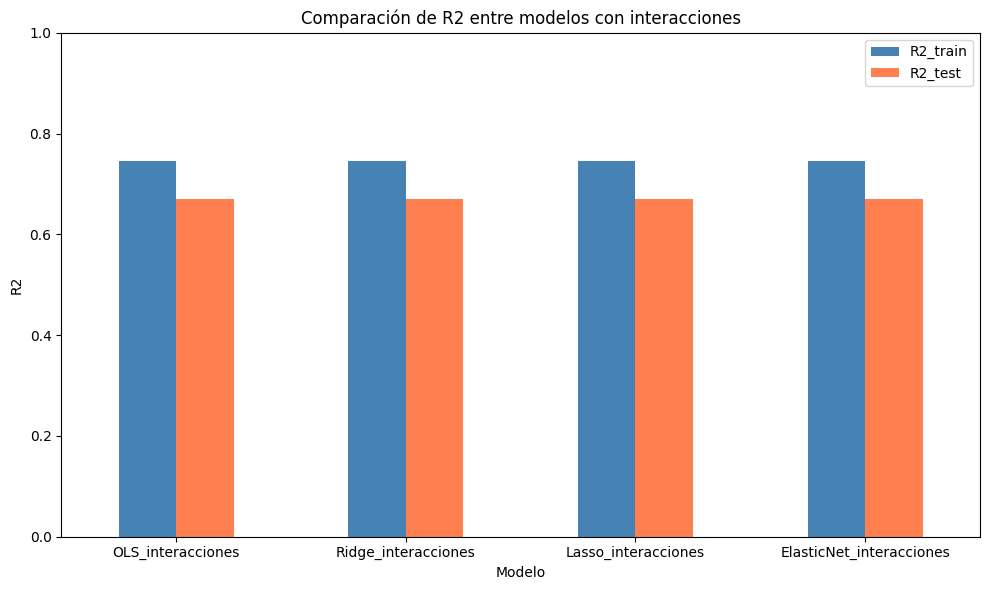

In [ ]:
df_resultados_int[['R2_train', 'R2_test']].plot(
    kind='bar',
    figsize=(10, 6),
    color=['steelblue', 'coral']
)

plt.title('Comparación de R2 entre modelos con interacciones')
plt.ylabel('R2')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

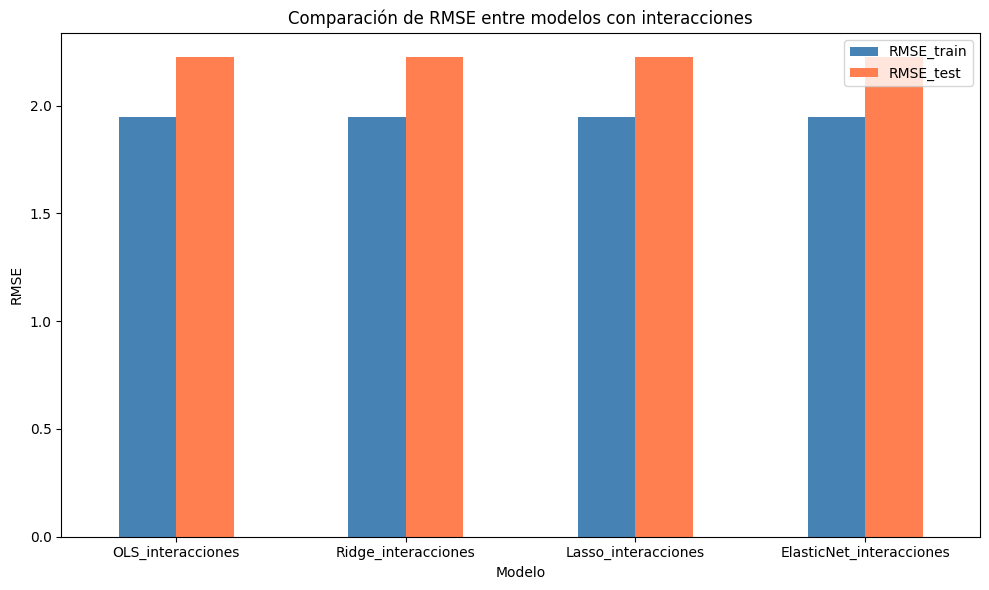

In [ ]:
df_resultados_int[['RMSE_train', 'RMSE_test']].plot(
    kind='bar',
    figsize=(10, 6),
    color=['steelblue', 'coral']
)

plt.title('Comparación de RMSE entre modelos con interacciones')
plt.ylabel('RMSE')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### 4.3.9 Observaciones de interés

La comparación debe centrarse en el R2 de prueba y en la significancia de los términos de interacción. Una interacción solo se justifica si mejora el desempeño fuera de muestra y si su coeficiente aporta evidencia estadística adicional.

Si los modelos penalizados presentan resultados prácticamente iguales al OLS, no existe evidencia de una colinealidad que requiera regularización. Si las interacciones no aumentan de manera material el R2 de prueba, el modelo lineal múltiple de la sección 4.1 continúa siendo la alternativa más interpretable y estable.

#### 4.3.10 Análisis de significancia de factores

Se evalúa la significancia individual de los efectos principales y de las interacciones mediante pruebas t. La prueba F permite valorar la significancia global del modelo ajustado después de retirar las observaciones atípicas e influyentes.

In [ ]:
tabla_significancia_int = pd.DataFrame({
    'Factor': model_int_filt.params.index,
    'Coeficiente': model_int_filt.params.values,
    'Error_estandar': model_int_filt.bse.values,
    't': model_int_filt.tvalues.values,
    'p_valor': model_int_filt.pvalues.values
})


tabla_significancia_int['Significativo_5%'] = np.where(tabla_significancia_int['p_valor'] < 0.05,'Sí','No')

tabla_significancia_int = tabla_significancia_int.sort_values('p_valor')

display(tabla_significancia_int)

,Factor,Coeficiente,Error_estandar,t,p_valor,Significativo_5%
0,const,61.613236,0.068446,900.178950,0.000000e+00,Sí
1,num__Hours_Studied,1.786719,0.010408,171.668103,0.000000e+00,Sí
2,num__Attendance,2.322878,0.008489,273.629076,0.000000e+00,Sí
4,num__Previous_Scores,0.713245,0.007513,94.935837,0.000000e+00,Sí
6,num__Physical_Activity,0.242673,0.004588,52.889923,0.000000e+00,Sí
12,ord__Access_to_Resources,0.991146,0.023002,43.089381,0.000000e+00,Sí
15,ord__Teacher_Quality,0.503544,0.007680,65.565126,0.000000e+00,Sí
14,ord__Family_Income,0.490570,0.006178,79.412264,0.000000e+00,Sí
19,bin__Extracurricular_Activities,0.503275,0.009320,54.001990,0.000000e+00,Sí
18,ord__Distance_from_Home,-0.498364,0.006892,-72.308558,0.000000e+00,Sí


La tabla identifica explícitamente los términos de interacción mediante la columna Es_interaccion. Para conservar una interacción en el modelo final, debe tener un p-valor inferior a 0.05 y contribuir a una mejora material del R2 de prueba. En caso contrario, debe preferirse el modelo lineal múltiple sin interacciones por su mayor interpretabilidad.

## 5. Pipeline

![Metodología](images/metodologia.png)

## 6. Conclusiones

**Modelo Lineal**

![Modelo lineal](images/modelolineal.png)


**Modelo Polinomial**

![Modelo polinomial](images/modelopolinomial.png)


**Modelo Lineal con Interacciones**

![Modelo lineal con interacciones](images/modelointeracciones.png)

**Coeficientes y P-Value del mejor modelo** \
Modelo Polinomial

![Coeficientes del modelo polinomial](images/coef.png)

- De acuerdo con el R² de prueba, el modelo Lasso polinomial obtuvo el mejor desempeño observado (R² = 0.6743). Superó ligeramente al mejor modelo lineal, Lasso (R² = 0.6707), y a los modelos con interacciones (R² = 0.6702). Sin embargo, la diferencia es reducida, por lo que la mejora predictiva del término polinomial debe considerarse modesta.

- Las cuatro versiones de cada especificación  produjeron resultados prácticamente idénticos. Esto indica que la regularización no genera una mejora. Aunque Lasso polinomial presenta el mayor R², OLS polinomial, Ridge polinomial y ElasticNet polinomial difieren por solo 0.0001 puntos de R².

- En el modelo polinomial, el término `Tutoring_Sessions_Sq` es positivo y estadísticamente significativo (coeficiente = 0.5312, p < 0.001). Dado a esto, existe evidencia de una relación no lineal y positiva entre las sesiones de tutoría y la calificación esperada. Es de mencionar que esta interpretación ya no se toma igual que los coeficientes lineales

- Los factores con relaciones positivas más fuertes son `Attendance` (+2.2750), `Hours_Studied` (+1.7222), `Internet_Access` (+1.0252), `Access_to_Resources` (+0.9864) y `Parental_Involvement` (+0.9780). En sentido contrario, `Learning_Disabilities` (−0.8683) y `Distance_from_Home` (−0.4815) presentan asociaciones negativas significativas con `Exam_Score`. Esto en su mayoría coincidiendo con lo mencionado esperado previamente.

- `Sleep_Hours`, `School_Type` y `Gender` no son estadísticamente significativos en esta especificación (p > 0.05). Por tanto, no hay evidencia suficiente para atribuirles una realción predictiva independiente con la calificación.

- Finalmente, las interacciones no mejoraron de manera relevante el R² de prueba. Esto nos indica que es posible que el dataset esta hecho a medida para una regresión lineal simple al igual que es sintético.

## 7. Referencias


- James, G., Witten, D., Hastie, T., Tibshirani, R. y Taylor, J. (2023). *An Introduction to Statistical Learning: with Applications in Python*. Springer. Capítulos 3, 6 y 7.
- Laboratorio de regresión 1. Regresión lineal simple, residuos, RSS, RSE y $R^2$.
- Laboratorio de regresión 2. Significancia de factores, errores estándar, pruebas de hipótesis, *p-values*, regresión múltiple e interacciones.
- Laboratorio de regresión 3. Exploración, limpieza y validación de factores del conjunto de datos.
- Laboratorio de regresión 4. Modelos penalizados, Ridge, Lasso, selección de $\alpha$ y comparación de desempeño.
- Zou, H. y Hastie, T. (2005). “Regularization and Variable Selection via the Elastic Net”. *Journal of the Royal Statistical Society: Series B*, 67(2), 301-320.